In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("RetailIQ Sales Forecasting started!")

RetailIQ Sales Forecasting started!


In [2]:
# ===== LOAD CLEAN SALES DATA =====

file_path = "../data/processed/clean_sales_data.csv"

sales_df = pd.read_csv(file_path)

sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

print("Sales data loaded successfully!")
print("Rows:", len(sales_df))

Sales data loaded successfully!
Rows: 392692


In [3]:
# ===== CREATE MONTHLY REVENUE =====

monthly_sales = (
    sales_df
    .set_index("InvoiceDate")
    .resample("ME")["Revenue"]
    .sum()
    .reset_index()
)

monthly_sales.columns = ["Month", "Revenue"]

display(monthly_sales)

,Month,Revenue
0,2010-12-31,570422.730
1,2011-01-31,568101.310
2,2011-02-28,446084.920
3,2011-03-31,594081.760
4,2011-04-30,468374.331
5,2011-05-31,677355.150
6,2011-06-30,660046.050
7,2011-07-31,598962.901
8,2011-08-31,644051.040
9,2011-09-30,950690.202


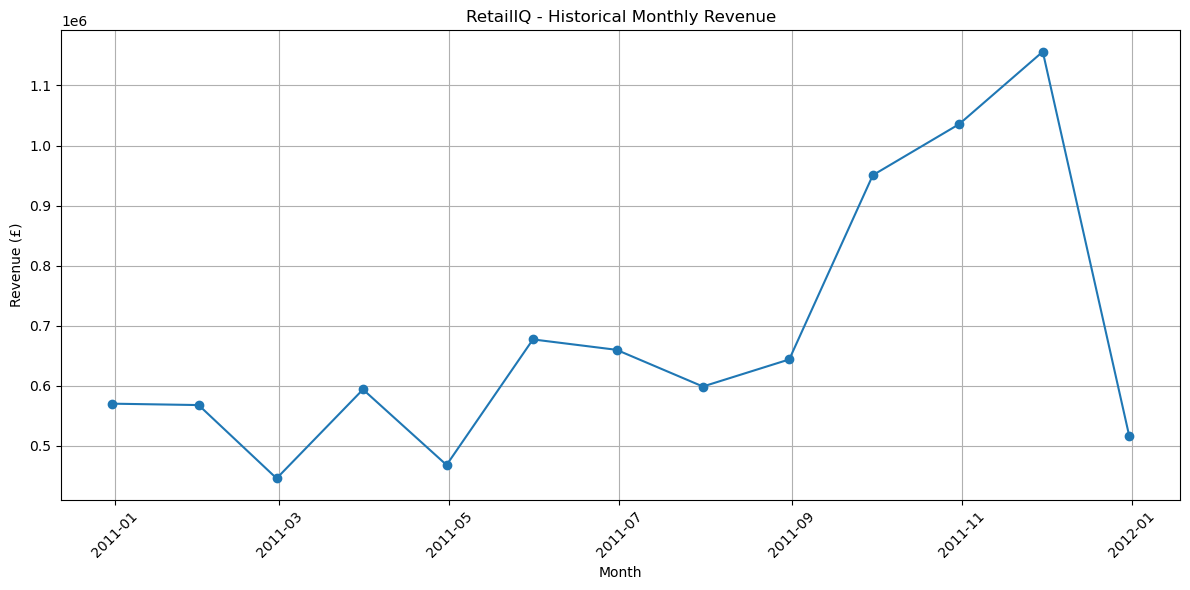

In [4]:
# ===== HISTORICAL MONTHLY REVENUE =====

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o"
)

plt.title("RetailIQ - Historical Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression

# ===== PREPARE TIME VARIABLE =====

monthly_sales["TimeIndex"] = np.arange(len(monthly_sales))

X = monthly_sales[["TimeIndex"]]
y = monthly_sales["Revenue"]

model = LinearRegression()

model.fit(X, y)

print("Forecasting model trained successfully!")

Forecasting model trained successfully!


In [6]:
# ===== MODEL PREDICTIONS =====

monthly_sales["PredictedRevenue"] = model.predict(X)

display(
    monthly_sales[
        ["Month", "Revenue", "PredictedRevenue"]
    ]
)

,Month,Revenue,PredictedRevenue
0,2010-12-31,570422.730,475209.111352
1,2011-01-31,568101.310,509946.168357
2,2011-02-28,446084.920,544683.225363
3,2011-03-31,594081.760,579420.282368
4,2011-04-30,468374.331,614157.339374
5,2011-05-31,677355.150,648894.396379
6,2011-06-30,660046.050,683631.453385
7,2011-07-31,598962.901,718368.510390
8,2011-08-31,644051.040,753105.567396
9,2011-09-30,950690.202,787842.624401


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ===== MODEL EVALUATION =====

mae = mean_absolute_error(
    monthly_sales["Revenue"],
    monthly_sales["PredictedRevenue"]
)

rmse = np.sqrt(
    mean_squared_error(
        monthly_sales["Revenue"],
        monthly_sales["PredictedRevenue"]
    )
)

print("===== FORECAST MODEL PERFORMANCE =====")
print(f"MAE: £{mae:,.2f}")
print(f"RMSE: £{rmse:,.2f}")

===== FORECAST MODEL PERFORMANCE =====
MAE: £134,044.65
RMSE: £169,371.23


In [8]:
# ===== FORECAST NEXT 3 MONTHS =====

future_periods = 3

last_time_index = monthly_sales["TimeIndex"].max()

future_indices = np.arange(
    last_time_index + 1,
    last_time_index + future_periods + 1
)

future_predictions = model.predict(
    future_indices.reshape(-1, 1)
)

future_dates = pd.date_range(
    start=monthly_sales["Month"].max() + pd.offsets.MonthEnd(1),
    periods=future_periods,
    freq="ME"
)

forecast = pd.DataFrame({
    "Month": future_dates,
    "ForecastRevenue": future_predictions
})

display(forecast)

c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Month,ForecastRevenue
0,2012-01-31,926790.852423
1,2012-02-29,961527.909429
2,2012-03-31,996264.966434


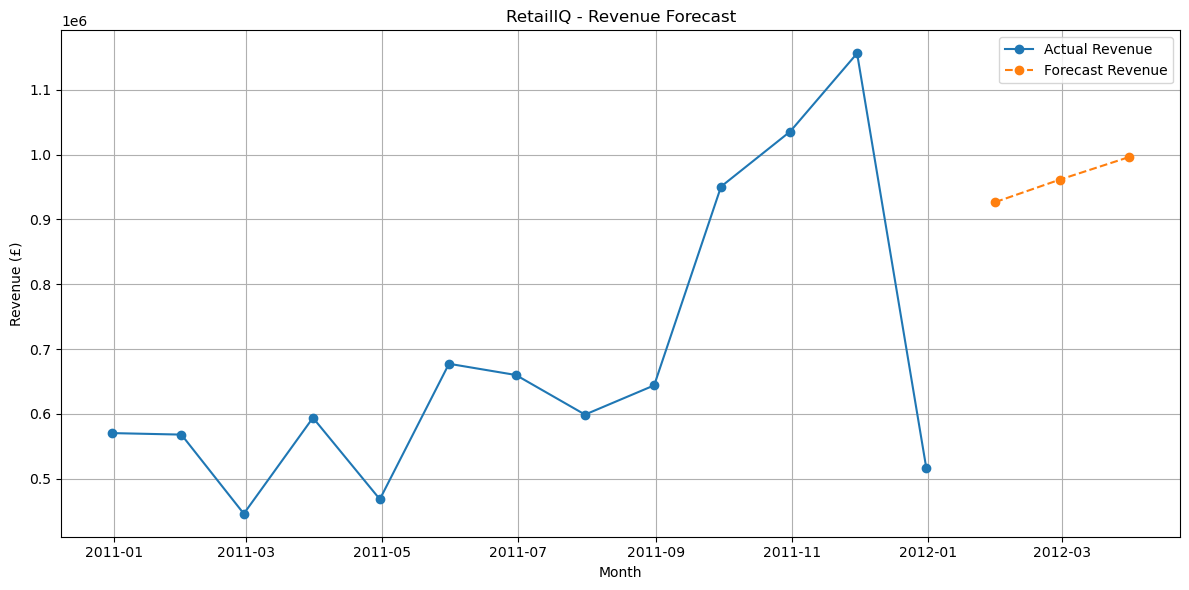

In [9]:
# ===== ACTUAL VS FORECAST =====

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Revenue"],
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    forecast["Month"],
    forecast["ForecastRevenue"],
    marker="o",
    linestyle="--",
    label="Forecast Revenue"
)

plt.title("RetailIQ - Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# ===== SAVE FORECAST =====

forecast.to_csv(
    "../data/processed/revenue_forecast.csv",
    index=False
)

print("Revenue forecast saved successfully!")

Revenue forecast saved successfully!
